# Highway Car Counter Project - YOLOv11

This notebook and the `main.py` file are located in the same folder.

The `main.py` file is a Python file that can be run directly from the terminal. This notebook, on the other hand, is designed to be run step by step.

The `main.py` file works according to the YOLOv8 version.


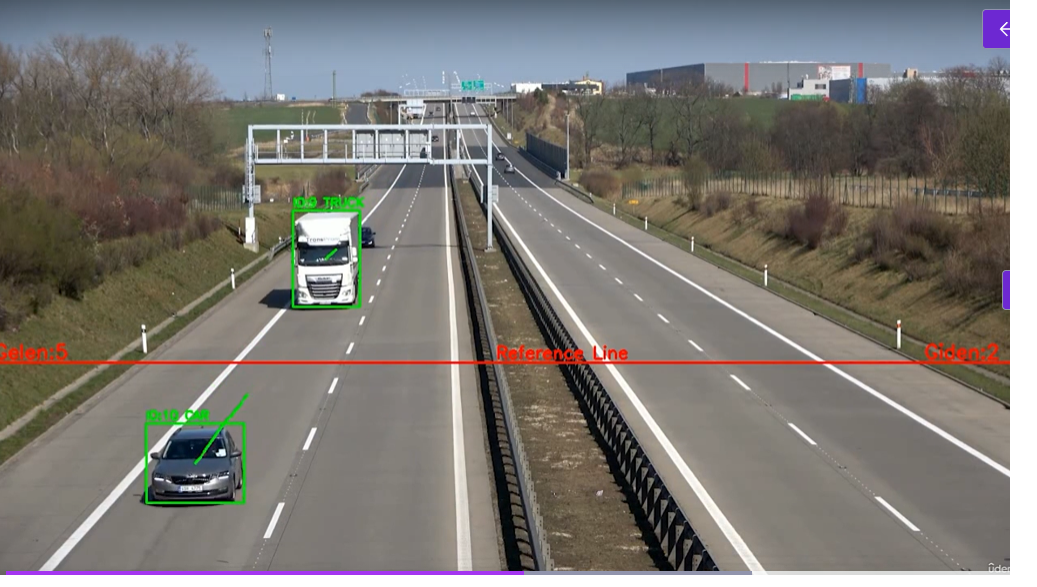

Detailed mind map for this notebook:
(The detailed version is available in the folder; a more general version is provided here.)

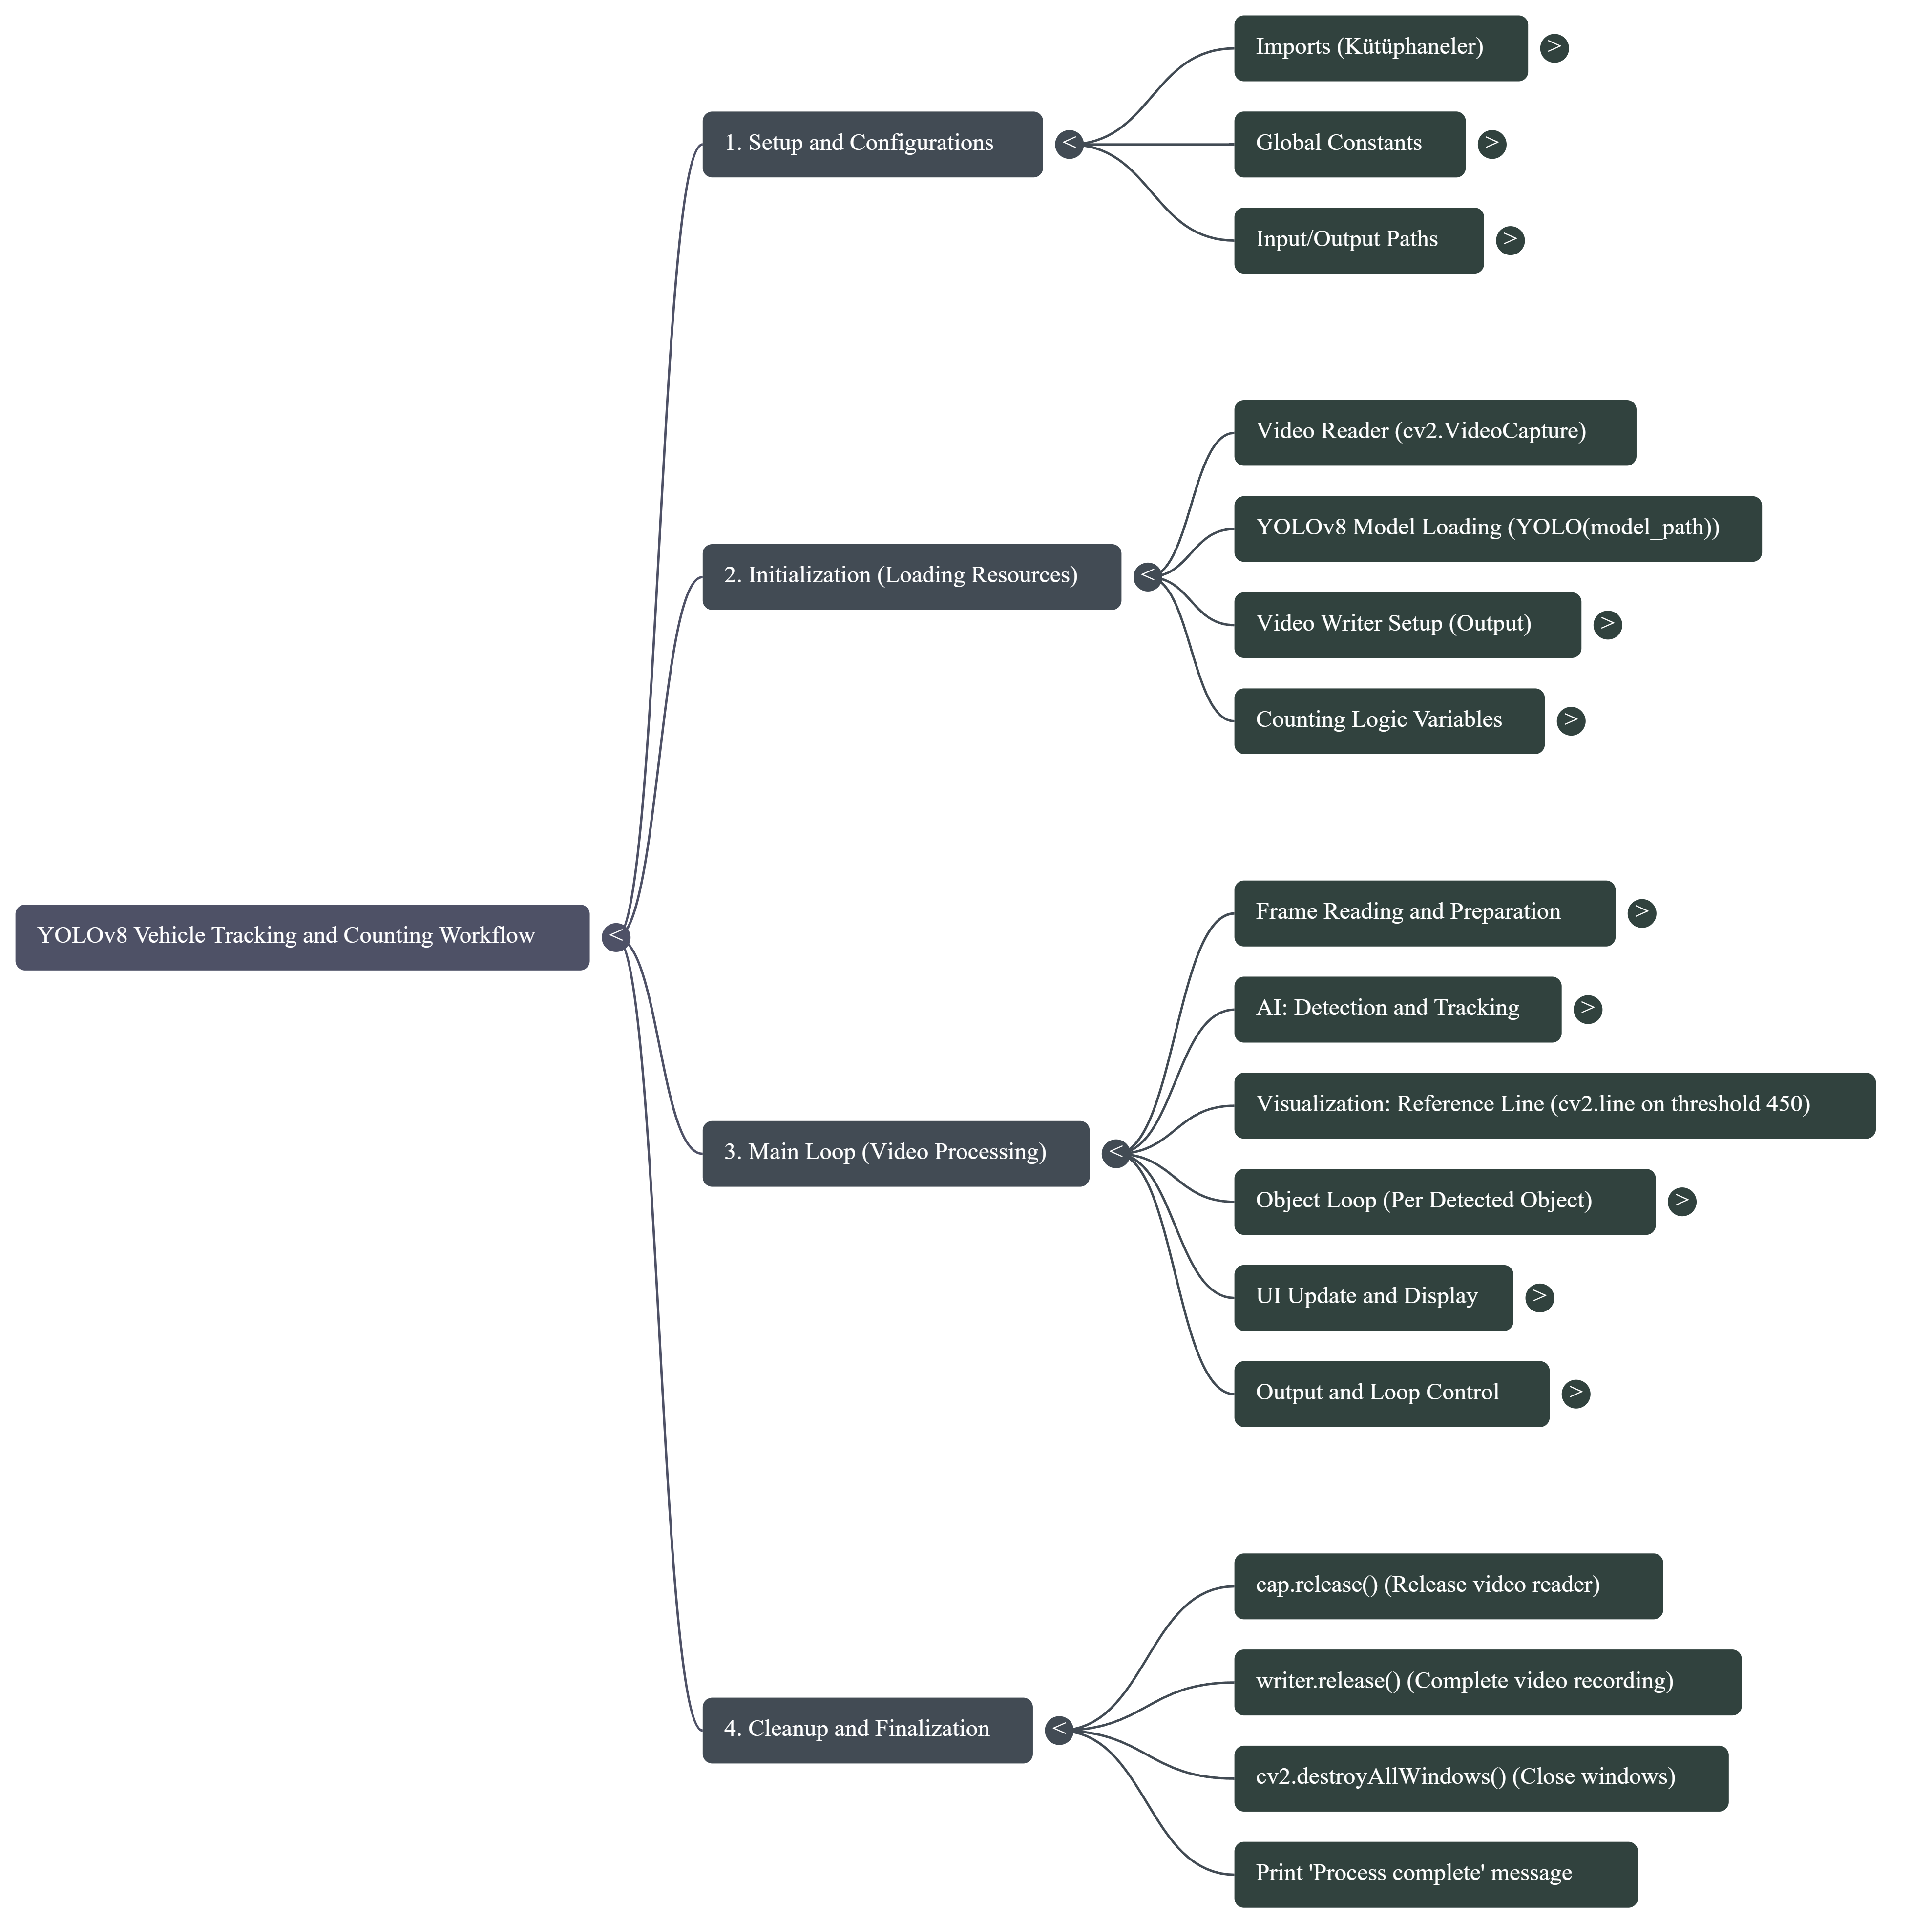

## 1. Importing the Required Libraries and Environment Settings


**NOTE:**

In some of the code cells below, you may experience a version compatibility issue between NumPy and SciPy. To fix this, run the following update commands in the terminal. After that, you should **restart the kernel**.


pip install --upgrade numpy

python.exe -m pip install --upgrade pip

pip install --upgrade scipy


In section 7, during the video processing part, you may encounter an OpenCV error. In that case, you may need to uninstall the current OpenCV version and install it again.

You can get support from an LLM during these steps.


In [1]:
import os

# [EXPERT NOTE] This line is used to prevent an "OMP: Error #15" issue
# that may occur especially in macOS or some Windows environments
# such as Jupyter, PyCharm, and similar tools.
#
# This error usually happens when multiple OpenMP libraries are loaded.
# It is not related to the logic of the code; it is related to environment compatibility.

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import cv2  # The main library for image processing (OpenCV)

import imutils  # Helper functions for OpenCV, especially for easy resizing

import numpy as np  # Used for numerical operations and array management

from ultralytics import YOLO  # The main library that provides the YOLO model

from collections import defaultdict  # A default dictionary structure used to store tracking history

## 2. Visualization and Drawing Settings


In [3]:
# The constants below define the style of the boxes, lines, and texts
# that we will draw on the video.

In [4]:
# The colors are entered in BGR format, which is the format used by OpenCV.
# These settings define the colors of the lines and texts drawn on the video frame,
# as well as the font style.

color = (0, 255, 0)      # Green color in BGR format, used for successful tracking
color_red = (0, 0, 255)  # Red color in BGR format, used for the reference line and counting
thickness = 2            # Line thickness in pixels

font_scale = 0.5         # Text size scale
font = cv2.FONT_HERSHEY_SIMPLEX  # Font type to be used

## 3. Input and Output File Paths


In [5]:

# Path of the video that will be processed
video_path = "inference/test.mp4"

# Path of the trained YOLOv11 model to be used
# Here, the "small" model is selected, but a stronger model can also be used.
model_path = "models/yolo11s.pt"



## 4. Reading the Video and Loading the Model


In [6]:
# Create a VideoCapture object to read the video from disk
cap = cv2.VideoCapture(video_path)

# Load the pre-trained YOLOv11 model from the specified path into memory
model = YOLO(model_path)

## 5. Video Writing / Output Settings


In [7]:
# We define the resolution of our output video: width and height.

# These values should be consistent with the `imutils.resize` function
# that will be used during processing.
width = 1280
height = 720

- In the code below, `fourcc` stands for "Four-Character Code".

- It is a unique 4-byte / 4-character identifier used to define a video codec,
- which means a compressor/decompressor.

- When you save a video file, the image pixels, which contain millions of data points,
- are compressed using a codec.

- When you play the video file, the video player uses the same codec to decompress
- that data and convert it back into visible images.

- The `fourcc` code tells the video writer, and later the video player,
- which codec should be used.

In [8]:
# We select the codec, meaning the video compression format,
# that will be used to save the output video.

# 'XVID' is a commonly used format that is compatible with Windows.

fourcc = cv2.VideoWriter_fourcc(*'XVID')

# VideoWriter object:
# (file_name, codec, frames_per_second, (width, height))

writer = cv2.VideoWriter("video_output.avi", fourcc, 20.0, (width, height))

# "video_output.avi":
# The name and location of the video file that will be saved.

# fourcc:
# The codec that will be used to compress the video,
# such as XVID, which was defined in the previous step.

# 20.0:
# The FPS value of the output video.
# FPS stands for Frames Per Second, meaning how many frames are shown in one second.

# (width, height):
# The resolution of the output video, meaning its width and height.

## 6. Initial Variables for Vehicle Tracking and Counting

In [9]:
# We specify the class IDs of the objects we are interested in counting.
# In the COCO dataset:
# 2 = car, 3 = motorcycle, 5 = bus, 7 = truck

vehicle_ids = [2, 3, 5, 7]

In [10]:
# `defaultdict` automatically creates an empty list (`lambda: []`)
# for each `track_id`.

# This will be used to store the recent positions, or centroids,
# of each tracked vehicle.

track_history = defaultdict(lambda: [])

In [11]:
# Dictionaries that will be used for counting.

# When a vehicle crosses the line, its ID will be added to one of these dictionaries.

# Using a dictionary prevents the same vehicle from being counted multiple times,
# especially if it pauses or stays near the counting line.
# This works because dictionary keys must be unique.

up = {}    # Vehicles moving upward / to the right side
down = {}  # Vehicles moving downward / to the left side

In [12]:
# The position of the horizontal reference line on the y-axis, in pixels.
# We will use this line to check whether vehicles have crossed it.

# This value can be adjusted by checking the video.
# In the image coordinate system, the top-left corner is (0, 0), meaning (x, y).
# For this video, the bottom-left corner has y = 720.

threshold = 450

## 7. Main Video Processing Loop

**NOTE:**

When the code block below runs successfully, a new window will open and vehicle counting will start.

In the output area below the cell, information about each processed frame will be displayed.

As a result of the following code line, the processed video will also be saved as `"video_output.avi"`.

In [13]:
while True:
    # Read the next frame from the video.
    # `ret` is a boolean value that shows whether the frame was read successfully.
    # `frame` contains the actual image data.
    ret, frame = cap.read()  # Tries to read the next video frame from the `cap` object, which is a cv2.VideoCapture object.

    # If `ret` is False, it means the video has ended or a reading error has occurred.
    if ret == False:
        break  # End the loop

    # [IMPORTANT] Resize the image.
    # This increases processing speed and ensures that fixed pixel values,
    # such as `threshold`, work consistently.
    frame = imutils.resize(frame, width=1280)  # Same value as the one used in section 5

    # [MODEL EXECUTION]
    # Run the YOLOv11 model in `track` mode. It will track all detected objects.
    # `persist=True`: Allows the model to remember and track objects across frames.
    # `verbose=False`: Prevents detailed logs from being printed to the console.
    # We disable it because information will already be shown on each frame.

    results = model.track(frame, persist=True, verbose=False)[0]

    # Convert the detected object data into a NumPy array.
    # This converts the raw detection results returned by the YOLOv11 model
    # into a NumPy array that is easier to process and draw with OpenCV.
    # Format: [x1, y1, x2, y2, track_id, score, class_id]

    bboxes = np.array(results.boxes.data.tolist(), dtype="int")  # Bounding boxes in each frame  # xyxy

    # --- 8. Visualization: Reference Line ---

    # Draw the reference line used for counting on the frame.
    # We previously set threshold = 450.
    cv2.line(frame, (0, threshold), (1280, threshold), color_red, thickness)
    # (0, threshold) means x = 0 and y = 450

    # Add a label to the line.
    # This label explains the purpose of the line by writing "Reference Line".
    cv2.putText(frame, "Reference Line", (620, 445), font, 0.7, color_red, thickness)

    # --- 9. Loop Over the Detected Objects ---
    # Since there may be multiple objects in the same frame,
    # we need a for loop to process each bounding box one by one.

    for box in bboxes:
        # Assign the values of the current bounding box to separate variables.
        x1, y1, x2, y2, track_id, score, class_id = box

        # Calculate the center point, or centroid, of the bounding box.
        # This point is used as the tracking point for the vehicle.
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        # Process only the vehicle classes that we are interested in.

        if class_id in vehicle_ids:

            # Get the class name from the class ID, for example: "CAR".
            class_name = results.names[int(class_id)].upper()  # car --> CAR

            # --- 10. Tracking History / Movement Trail Management ---

            # [INFO] CTRL + K + C / CTRL + K + U
            # These shortcuts can be used to comment or uncomment code.
            # print("BBoxes: ", (x1, y1, x2, y2))
            # print("Class: ", class_name)
            # print("ID: ", track_id)

            # Get the tracking history of the current vehicle using its track_id.
            track = track_history[track_id]

            # Add the new center point, or centroid, to the history.
            # This will be used to draw the movement trail.
            track.append((cx, cy))

            # To avoid making the history list too long,
            # both for performance and visual clarity,
            # remove the oldest position.
            # Here, we keep only the last 15 frames.
            if len(track) > 15:
                track.pop(0)

            # Convert the points in the tracking history into a format
            # that OpenCV can draw.
            # This changes the (x, y) coordinates in the `track` list
            # into the special format required by `cv2.polylines`.

            points = np.hstack(track).astype("int32").reshape((-1, 1, 2))

            # Draw the movement trail of the vehicle.
            cv2.polylines(frame, [points], isClosed=False, color=color, thickness=thickness)

            # --- 11. Visualization: Bounding Box and ID ---

            # Draw a green rectangle, or bounding box, around the detected vehicle.
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)

            # Write the vehicle ID and class name just above the bounding box.

            text = "ID:{} {}".format(track_id, class_name)
            cv2.putText(frame, text, (x1, y1 - 5), font, font_scale, color, thickness)
            # We use y1 - 5 to place the text slightly above the box.

            # In the image coordinate system, the origin is the top-left corner.
            # That is why we use x1 and y1 - 5.

            # --- 12. Counting Logic ---

            # In the image, the top-left corner is the point (0, 0).
            # As we move downward, the y value increases.
            # Here, we check whether the vehicle's center point, cy,
            # is very close to the reference line, threshold,
            # using a tolerance of 5 pixels.

            if cy > threshold - 5 and cy < threshold + 5:

                # Since there are two lanes in the video,
                # one for each direction, we divide the screen into two parts along the x-axis.

                # If the vehicle is on the left side of the line,
                # meaning cx < 670, which is approximately half of the screen width,
                # we count it as `down`, meaning incoming vehicles.
                # The full width is 1280 pixels.
                if cx < 670:
                    down[track_id] = x1, y1, x2, y2  # Add the ID to the dictionary

                # If the vehicle is on the right side of the line,
                # meaning cx > 670,
                # we count it as `up`, meaning outgoing vehicles.
                if cx > 670:
                    up[track_id] = x1, y1, x2, y2  # Add the ID to the dictionary

    # --- 13. Displaying the Counting Results ---

    # Print the current status to the console for debugging.
    print("UP Dictionary Keys: ", list(up.keys()))
    print("DOWN Dictionary Keys: ", list(down.keys()))

    # Get the total number of unique IDs in the `up` dictionary.
    # These are the vehicles going upward / outgoing in the video.
    up_text = "Outgoing:{}".format(len(list(up.keys())))

    # Get the total number of unique IDs in the `down` dictionary.
    # These are the vehicles coming downward / incoming in the video.
    down_text = "Incoming:{}".format(len(list(down.keys())))

    # Write the counting results on the video frame.
    # Suitable x and y coordinates should be selected.
    # Here, we use x = 1150 and y = threshold - 5 for the outgoing count.

    cv2.putText(frame, up_text, (1150, threshold - 5), font, 0.8, color_red, thickness)
    cv2.putText(frame, down_text, (0, threshold - 5), font, 0.8, color_red, thickness)

    # --- 14. End of Loop: Saving and Displaying ---

    # Write the processed frame, with all drawings added, to the output video file.
    writer.write(frame)

    # Display the processed frame in a window named "Test".
    cv2.imshow("Test", frame)

    # Check whether the user has pressed the `q` key.
    # `cv2.waitKey(10)` waits for 10 milliseconds.
    if cv2.waitKey(10) & 0xFF == ord("q"):
        break  # If the `q` key is pressed, stop the main loop

UP Dictionary Keys:  []
DOWN Dictionary Keys:  []
UP Dictionary Keys:  []
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictionary Keys:  []
UP Dictionary Keys:  [np.int64(1)]
DOWN Dictio

## 15. Cleanup and Closing


In [14]:
# Release the video reading object
cap.release()

# Release the video writing object.
# This is important to make sure the output file is closed and saved properly.
writer.release()

# Close all OpenCV windows
cv2.destroyAllWindows()

print("[INFO].. The video was processed successfully and saved as 'video_output.avi'!")

[INFO].. The video was processed successfully and saved as 'video_output.avi'!
